# Spectral trajectory baseline comparison

Recreates the two-panel bar chart from `analyze_new_spectral.ipynb` using the three baseline/Spectral-20 pairs referenced by the trajectory plot in `neurips_figures1.ipynb`:

- Pretrained → Spectral-20 Pretrained
- BoN-10 → Spectral-20 BoN-10 Pretrained
- DRAKES → Spectral-20 DRAKES

The top panel reports the fraction with evaluation ΔΔG > 0. The bottom panel reports success, defined as evaluation ΔΔG > 0 and scRMSD < 2.

In [1]:
from pathlib import Path
import warnings

import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd


def find_repo_root(start=Path.cwd()):
    """Find the DRAKES checkout regardless of the notebook launch directory."""
    for candidate in (start, *start.parents):
        if (candidate / "drakes_protein").is_dir():
            return candidate
    raise FileNotFoundError("Could not find the DRAKES repository root from the current directory")


repo_root = find_repo_root()
data_root = repo_root / "drakes_protein/fmif/eval_results/followups/exps2/"

# Baseline and Spectral-20 CSVs corresponding to the three trajectory curves.
csv_pairs = {
    "Pretrained": {
        "baseline": data_root / "pretrained_test.csv",
        "spectral": data_root / "pretrained_test_ddg_bon_N=1_feedbacksteps=5_feedbackmethod=spectral_maxspecorder=20_masks=8192_rmax=False_.csv",
    },
    "BoN-10": {
        "baseline": data_root / "pretrained_test_ddg_bon_N=10.csv",
        "spectral": data_root / "pretrained_test_ddg_bon_N=10_feedbacksteps=5_feedbackmethod=spectral_maxspecorder=20_masks=8192_rmax=True_.csv",
    },
    "DRAKES": {
        "baseline": data_root / "drakes_test.csv",
        "spectral": data_root / "drakes_test_ddg_bon_N=1_feedbacksteps=5_feedbackmethod=spectral_maxspecorder=20_masks=8192_rmax=False_.csv",
    },
}

for method, pair in csv_pairs.items():
    for variant, path in pair.items():
        if not path.is_file():
            raise FileNotFoundError(f"Missing {method} {variant} CSV: {path}")

print("Validated all six CSV paths.")

Validated all six CSV paths.


In [2]:
def compute_eval_stats(path):
    """Compute the same evaluation statistics used by neurips_figures1."""
    df = pd.read_csv(path)
    stats = {}

    if "ddg_eval" in df:
        ddg_eval = df["ddg_eval"].to_numpy()
        stats["ddg"] = np.mean(ddg_eval)
        stats["ddg_std"] = np.std(ddg_eval)
        stats["pos_ddg_prop"] = np.mean(ddg_eval > 0)
    if "ddg" in df:
        ddg_align = df["ddg"].to_numpy()
        stats["ddg_align"] = np.mean(ddg_align)
        stats["ddg_align_std"] = np.std(ddg_align)
    if "scrmsd" in df:
        scrmsd = df["scrmsd"].to_numpy()
        stats["scrmsd"] = np.mean(scrmsd)
        stats["scrmsd_std"] = np.std(scrmsd)
        stats["low_scrmsd_prop"] = np.mean(scrmsd < 2)
    if "ddg_eval" in df and "scrmsd" in df:
        stats["success_rate"] = np.mean((df["ddg_eval"].to_numpy() > 0) & (df["scrmsd"].to_numpy() < 2))
    if "loglikelihood" in df:
        loglikelihood = df["loglikelihood"].to_numpy()
        stats["ll"] = np.mean(loglikelihood)
        stats["ll_std"] = np.std(loglikelihood)

    return stats


methods = list(csv_pairs)
stats_by_experiment = {}
table_rows = []

for method, pair in csv_pairs.items():
    for variant, path in pair.items():
        experiment = f"{method} — {variant.title()}"
        stats = compute_eval_stats(path)
        stats_by_experiment[(method, variant)] = stats
        table_rows.append({"experiment": experiment, **stats})

# Complete eval_stats table for all six experiments. Missing source columns appear as NaN.
eval_stats_table = pd.DataFrame(table_rows).set_index("experiment")
display(eval_stats_table.round(3))

# Convert proportions to percentages for the chart.
ddg_before = np.array([100 * stats_by_experiment[(method, "baseline")]["pos_ddg_prop"] for method in methods])
ddg_after = np.array([100 * stats_by_experiment[(method, "spectral")]["pos_ddg_prop"] for method in methods])
success_before = np.array([100 * stats_by_experiment[(method, "baseline")].get("success_rate", np.nan) for method in methods])
success_after = np.array([100 * stats_by_experiment[(method, "spectral")].get("success_rate", np.nan) for method in methods])

,ddg,ddg_std,pos_ddg_prop,ddg_align,ddg_align_std,scrmsd,scrmsd_std,low_scrmsd_prop,success_rate,ll,ll_std
experiment,,,,,,,,,,,
Pretrained — Baseline,-0.489,1.284,0.361,0.104,0.423,1.102,0.855,0.918,0.339,-147.845,43.314
Pretrained — Spectral,0.327,1.182,0.683,0.526,0.204,1.064,0.867,0.942,0.625,-146.500,42.901
BoN-10 — Baseline,0.093,1.225,0.594,0.454,0.203,1.088,0.829,0.924,0.561,-148.133,42.276
BoN-10 — Spectral,0.861,1.073,0.842,0.704,0.099,1.073,1.201,0.967,0.808,-147.544,41.351
DRAKES — Baseline,0.988,0.821,0.859,0.693,0.097,1.172,1.202,0.934,0.798,-157.516,41.561
DRAKES — Spectral,1.380,0.719,0.917,0.825,0.046,1.531,1.857,0.858,0.783,-157.684,40.209


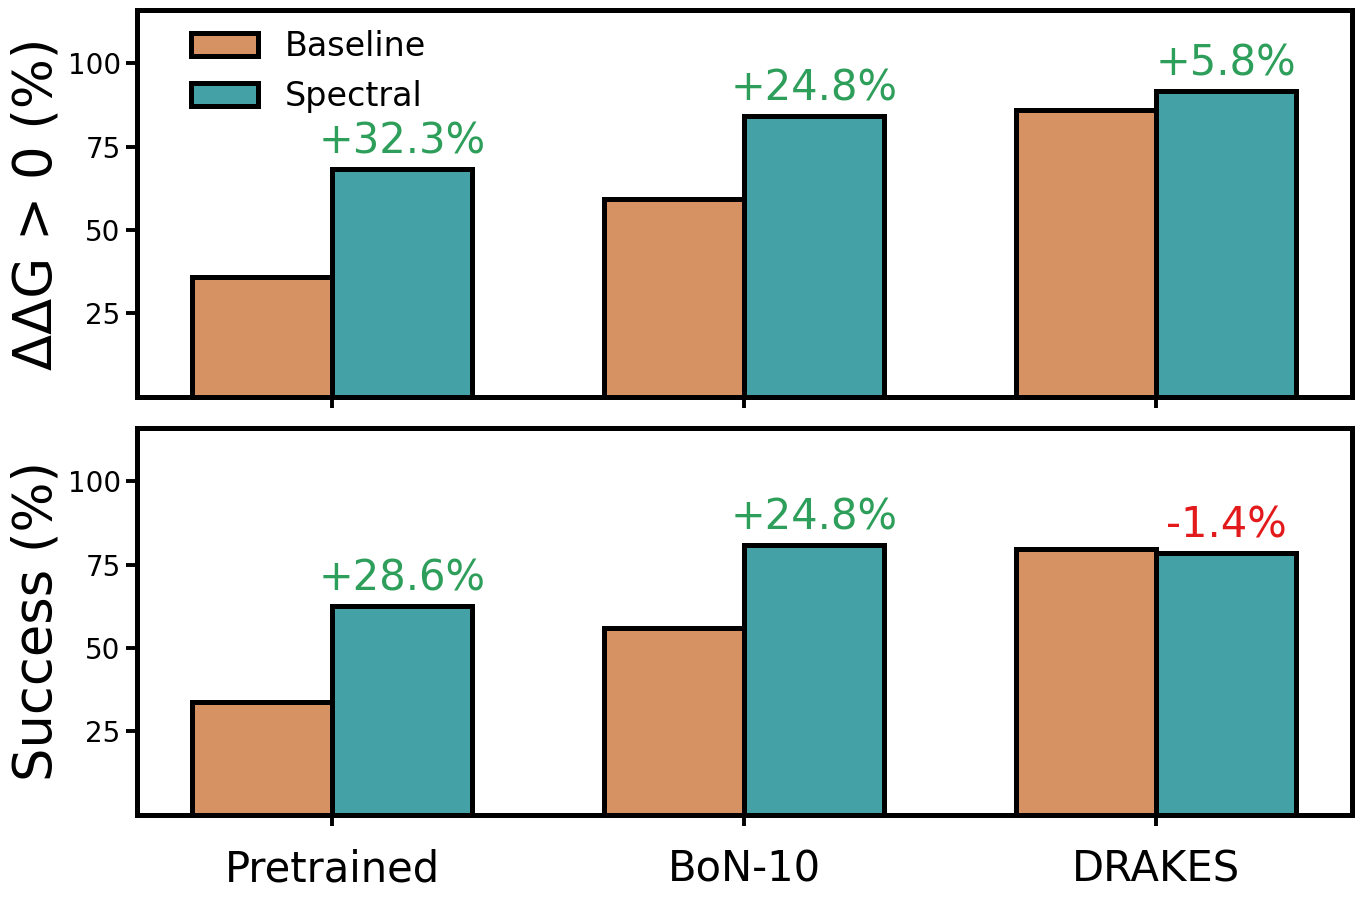

Saved: /u/sdickman/DRAKES/drakes_protein/fmif/fig_gen/spectral_trajectory_bar_comparison.pdf


In [3]:
mpl.rcParams.update({
    "font.family": "DejaVu Sans",
    "font.sans-serif": [
        "DejaVu Sans",
        "Arial",
        "Helvetica",
        "Liberation Sans",
    ],
    "mathtext.fontset": "dejavusans",
    "axes.linewidth": 3.0,
    "axes.labelsize": 26,
    "xtick.labelsize": 18,
    "ytick.labelsize": 20,
    "legend.fontsize": 24,
})

before_color = "#D79264"
after_color = "#44A2A6"
delta_green = "#2E9E5B"
drakes_success_text_color = "#E31A1C"  # vibrant red annotation only
missing_color = "#E31A1C"
x = np.arange(len(methods))
width = 0.34

fig, axes = plt.subplots(2, 1, figsize=(13.5, 9.0), sharex=True, constrained_layout=True)
fig.set_constrained_layout_pads(h_pad=0.10, hspace=0.04)

def draw_panel(ax, before, after, ylabel, show_legend=False, annotation_colors=None):
    if annotation_colors is None:
        annotation_colors = [delta_green] * len(methods)
    ax.bar(x - width / 2, before, width, color=before_color, edgecolor="black", linewidth=3.6, label="Baseline")
    ax.bar(x + width / 2, after, width, color=after_color, edgecolor="black", linewidth=3.6, label="Spectral")
    ax.set_ylabel(ylabel, fontsize=38)
    ax.set_ylim(0, 116)
    ax.set_yticks([25, 50, 75, 100])

    for i, (baseline_value, spectral_value) in enumerate(zip(before, after)):
        if np.isfinite(spectral_value):
            delta = spectral_value - baseline_value
            sign = "+" if delta >= 0 else ""
            ax.text(x[i] + width / 2, spectral_value + 2, f"{sign}{delta:.1f}%", ha="center", va="bottom", fontsize=30, color=annotation_colors[i])
        else:
            ax.text(x[i] + width / 2, 4, "N/A\n(no scRMSD)", ha="center", va="bottom", fontsize=17, color=annotation_colors[i])

    ax.grid(False)
    for spine in ax.spines.values():
        spine.set_linewidth(3.6)
    ax.tick_params(axis="both", width=2.8, length=8)
    if show_legend:
        ax.legend(loc="upper left", bbox_to_anchor=(0.02, 1.025), frameon=False)


draw_panel(axes[0], ddg_before, ddg_after, "ΔΔG > 0 (%)", show_legend=True)
success_annotation_colors = [delta_green, delta_green, drakes_success_text_color]
draw_panel(
    axes[1], success_before, success_after, "Success (%)",
    annotation_colors=success_annotation_colors,
)
axes[1].set_xticks(x)
axes[1].set_xticklabels(methods, fontsize=30)
axes[1].tick_params(axis="x", pad=16)

output_path = repo_root / "drakes_protein/fmif/fig_gen/spectral_trajectory_bar_comparison.pdf"
fig.savefig(output_path, bbox_inches="tight", dpi=300)
plt.show()
print(f"Saved: {output_path}")